In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

### TASK 1.1: Develop a *Line chart* using the functionality of pandas to show how Average automobile sales fluctuate from year to year


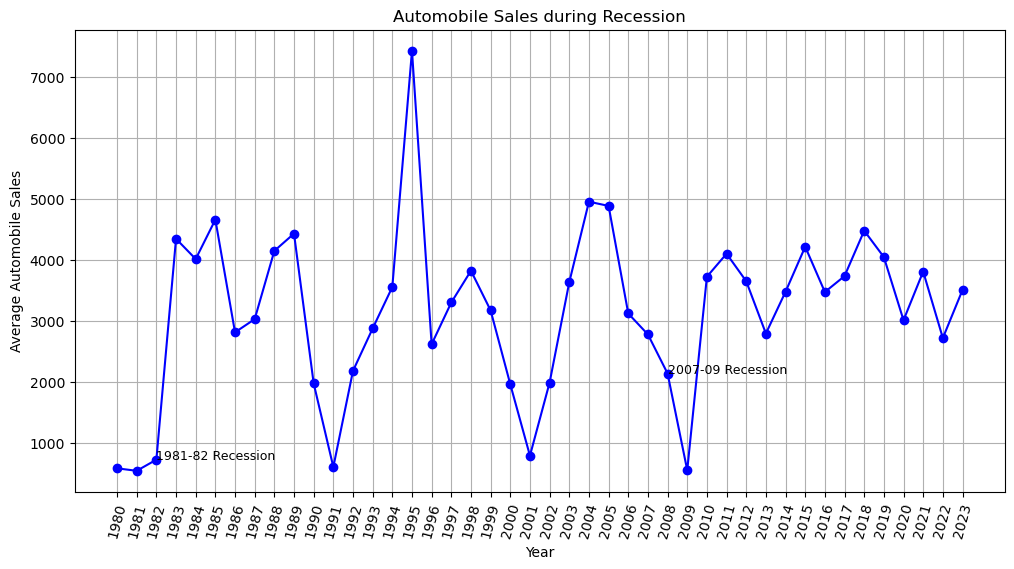

In [6]:
# Create yearly sales data
yearly_sales = df.groupby('Year')['Automobile_Sales'].mean()

# Plot
plt.figure(figsize=(12,6))
yearly_sales.plot(kind='line', marker='o', linestyle='-', color='blue')
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')
plt.xticks(range(1980, 2024), rotation=75)  # assuming years up to 2023
# Annotate recession years
plt.text(1982, yearly_sales[1982], '1981-82 Recession', fontsize=9)
plt.text(2008, yearly_sales[2008], '2007-09 Recession', fontsize=9)
# Alternatively, you could also annotate 2020
plt.grid(True)
plt.show()

### Include the following on the plot
ticks on x- axis with all the years, to identify the years of recession 
<br>annotation for at least two years of recession
<br>Title as Automobile Sales during Recession
<br> 


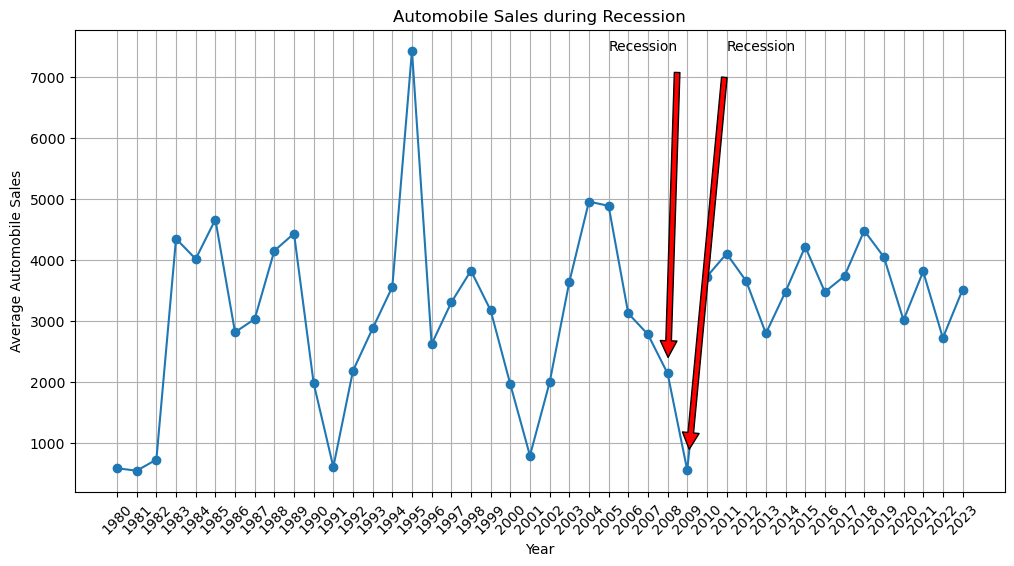

In [9]:
# Group yearly sales
yearly_data = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(12,6))

# Line plot
plt.plot(yearly_data.index, yearly_data.values, marker='o')

# Set all years on x-axis
plt.xticks(yearly_data.index, rotation=45)

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')

# Annotate at least two recession years
plt.annotate('Recession',
             xy=(2008, yearly_data.loc[2008]),
             xytext=(2005, yearly_data.max()),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.annotate('Recession',
             xy=(2009, yearly_data.loc[2009]),
             xytext=(2011, yearly_data.max()),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.grid(True)
plt.show()

####  TASK 1.2: How do trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.


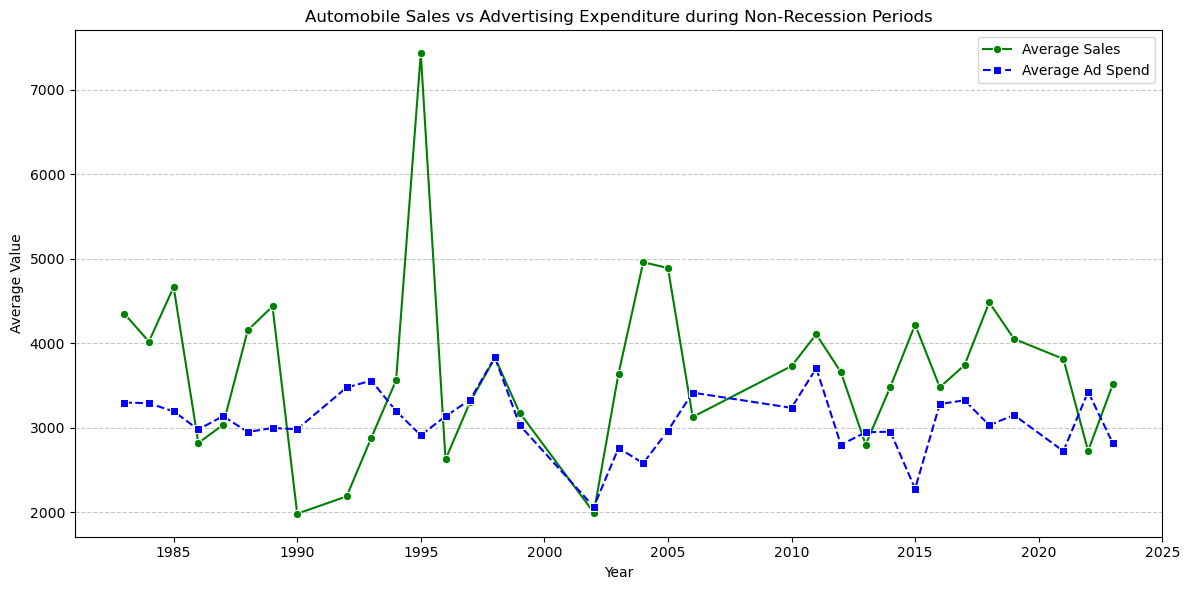

In [10]:
# Filter non-recession data
df_non_rec = df[df['Recession'] == 0]

# Aggregate by year
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales', marker='o',
             linestyle='-', color='green', label='Average Sales')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend', marker='s',
             linestyle='--', color='blue', label='Average Ad Spend')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Automobile Sales vs Advertising Expenditure during Non-Recession Periods')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### From the above plot, what insights have you gained?<br> Type in your answer below:


The graph shows that during non-recession periods, automobile sales are more volatile than advertising expenditure. While there are moments of alignment, sales often spike independently, suggesting other factors like market demand or economic conditions also play a significant role. The correlation between advertising and sales appears inconsistent over time.

### TASK 1.3: Use the functionality of **Seaborn Library** to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.


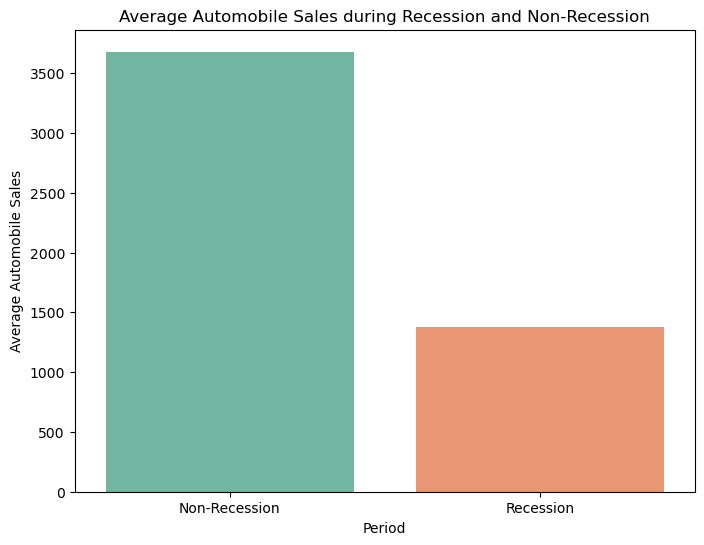

In [11]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',
            data=new_df, palette='Set2', legend=False)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

### Now you want to compare the sales of different vehicle types during a recession and a non-recession period
<br>We recommend that you use the functionality of **Seaborn Library** to create this visualization


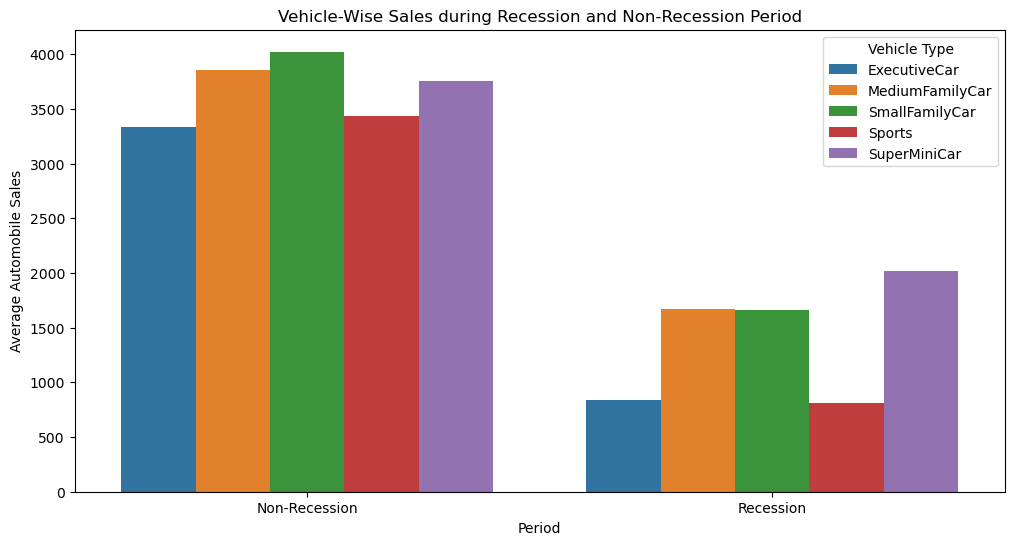

In [14]:
grouped = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.legend(title='Vehicle Type')
plt.show()

### From the above chart what insights have you gained on the overall sales of automobiles during recession? <br> Type your answer below:-



From the bar chart comparing vehicle types during recession and non-recession periods, we can conclude:

 Overall automobile sales decline significantly during recession.

 Almost all vehicle categories show a drop in average sales.

 Luxury, executive, and sports vehicles are the most affected, as consumers avoid high-priced purchases during economic uncertainty.

Smaller and more economical vehicles perform relatively better, as customers prefer budget-friendly options during recession.

### TASK 1.4: Use sub plotting to compare the variations in GDP during recession and non-recession period by developing line plots for each period.
<br>Now, you want to find more insights from the data to understand the reason. <br>Plot a two line charts using subplotting to answer:-
#### How did the GDP vary over time during recession and non-recession periods? 
<br>Make use of <u>add_subplot()</u> from Matplotlib for this comparision.


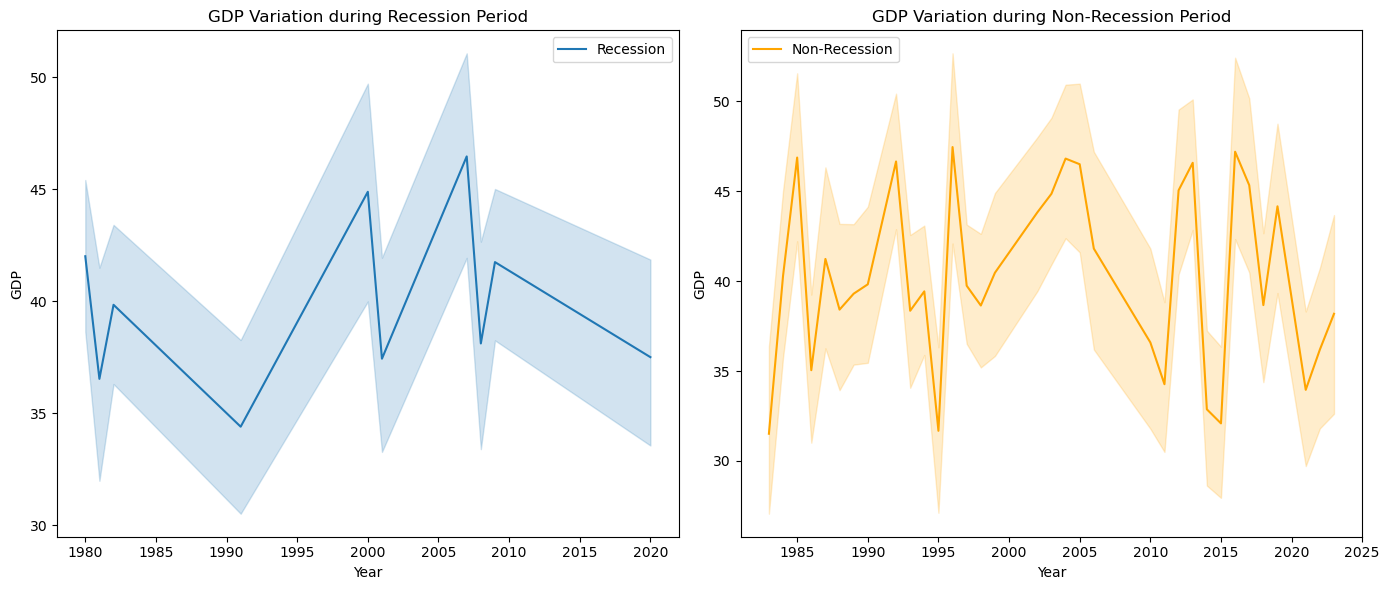

In [15]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig = plt.figure(figsize=(14, 6))

# Left subplot: Recession
ax0 = fig.add_subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

# Right subplot: Non‑recession
ax1 = fig.add_subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1, color='orange')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.
<br>How has seasonality impacted the sales, in which months the sales were high or low? Check it for non-recession years to understand the trend

##### Develop a Bubble plot for displaying Automobile Sales for every month and use Seasonality Weight for representing the size of each bubble<br>
Title this plot as 'Seasonality impact on Automobile Sales'


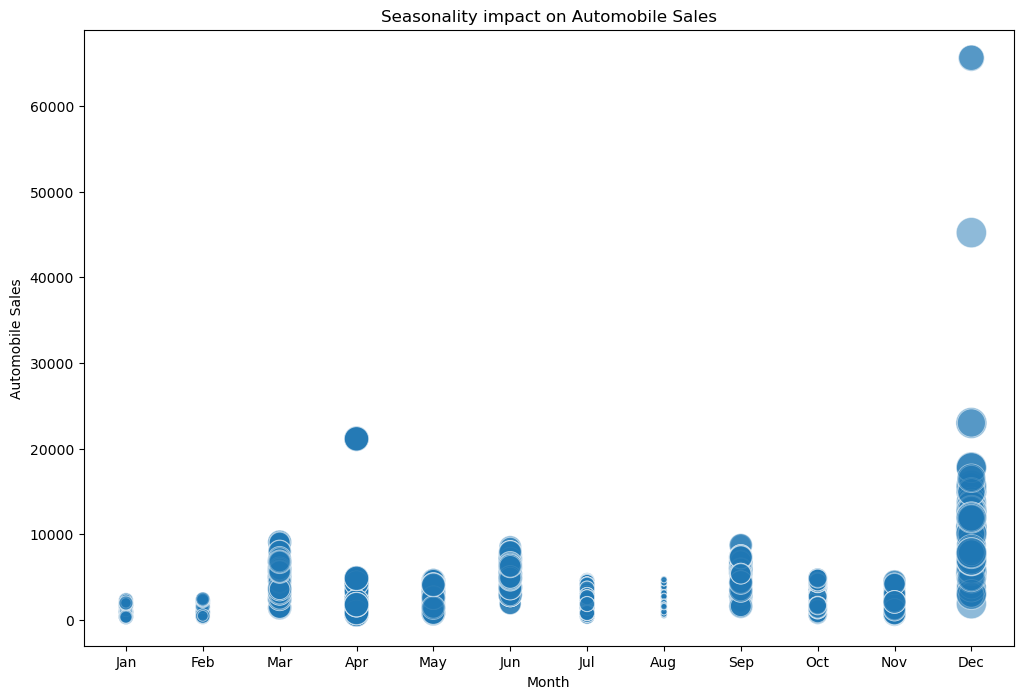

In [16]:
non_rec_data = df[df['Recession'] == 0]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales',
                size='Seasonality_Weight', sizes=(20, 500), alpha=0.5, legend=False)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()

 ### TASK 1.6: Use the functionality of Matplotlib to develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.
 #### From the data, develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recession periods.
 <br> Title this plot as 'Consumer Confidence and Automobile Sales during Recessions'


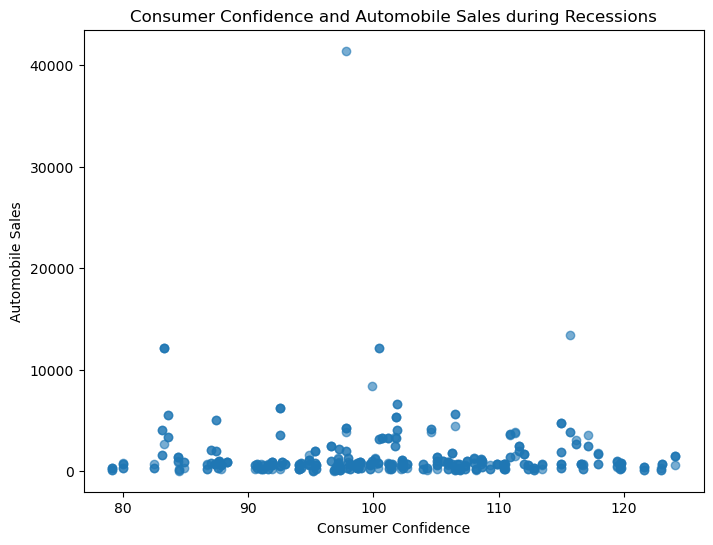

In [17]:
rec_data = df[df['Recession'] == 1]
plt.figure(figsize=(8, 6))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'], alpha=0.6)
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()


 ### How does consumer confidence relate to automobile sales during recessions?
 <br> Plot another scatter plot and title it as 'Relationship between Vehicle Price and Sales during Recessions'


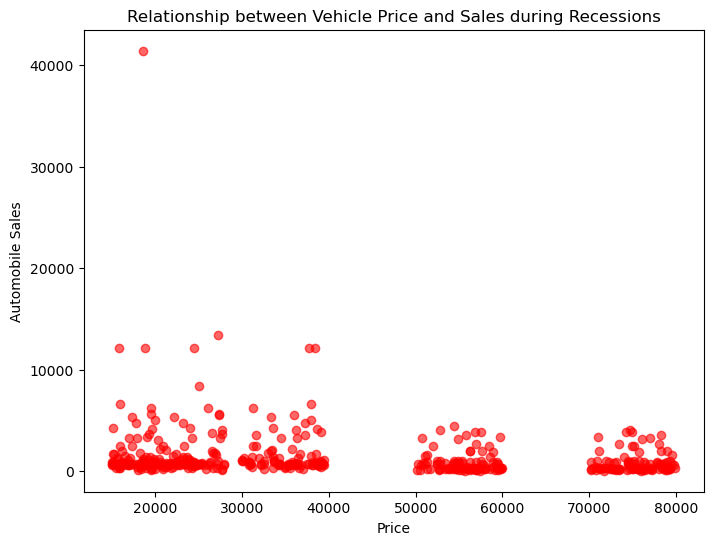

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], alpha=0.6, color='red')
plt.xlabel('Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.show()

 ### TASK 1.7: Create a pie chart to display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.
 <br>How did the advertising expenditure of XYZAutomotives change during recession and non-recession periods? 


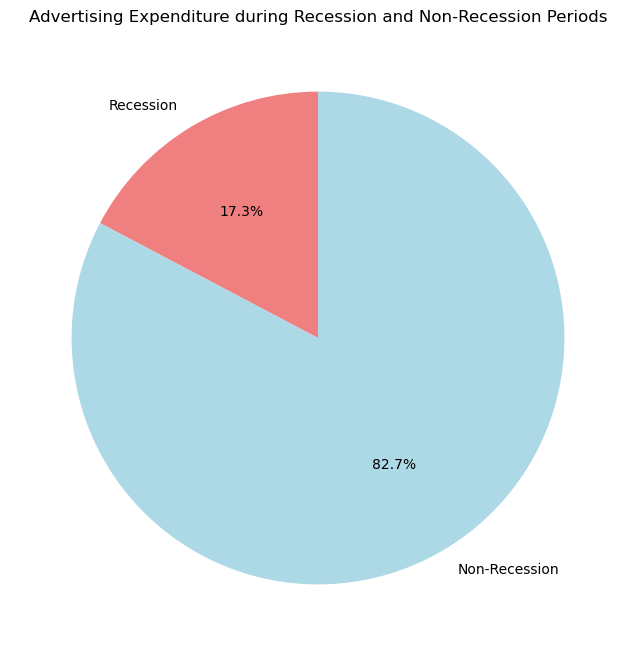

In [21]:
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['lightcoral', 'lightblue'])
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.show()

#### From the above plot, what insights do you find on the advertisement expenditure during recession and non recession periods?<br> Type your answer below:-


From the pie chart comparing advertisement expenditure during recession and non-recession periods, we can observe:

Advertisement expenditure is higher during non-recession periods.

 During recession, the company reduces its advertising spending.

This indicates that businesses tend to control marketing costs when the economy is weak.

In stable economic conditions (non-recession), companies invest more in advertising to boost sales and expand market share.

### TASK 1.8: Develop a pie chart to display the total Advertisement expenditure for each vehicle type during recession period.<br>
Can we observe the share of each vehicle type in total expenditure during recessions? 


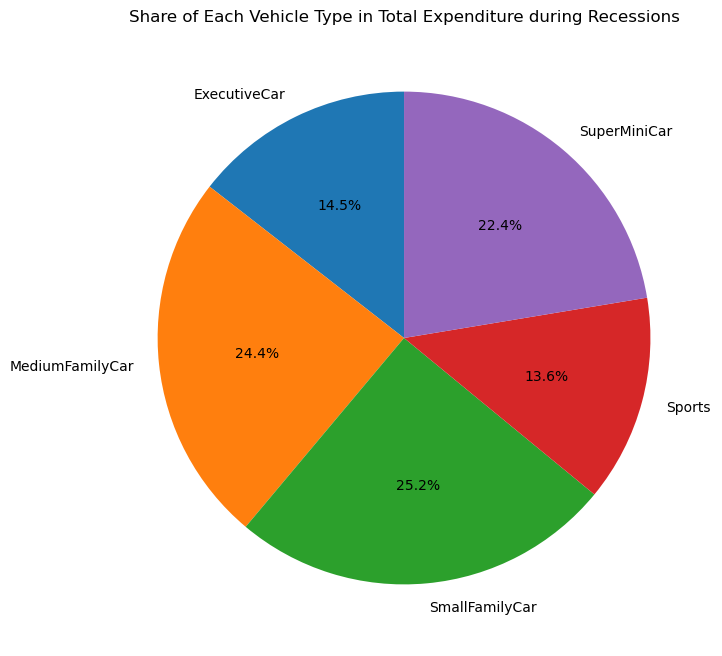

In [22]:
Rdata = df[df['Recession'] == 1]
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Share of Each Vehicle Type in Total Expenditure during Recessions')
plt.show()

 ### TASK 1.9: Develop a lineplot to analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.
 <br>Analyze the effect of the unemployment rate on vehicle type and sales during the Recession Period
 #### You can create a lineplot and title the plot as 'Effect of Unemployment Rate on Vehicle Type and Sales'


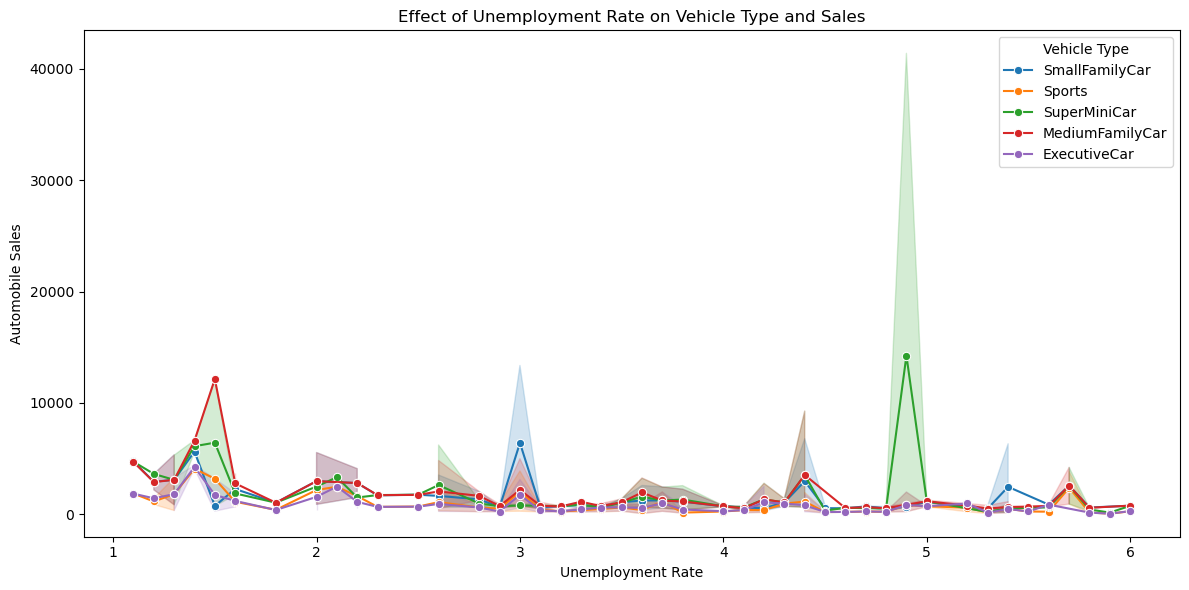

In [28]:
df_rec = df[df['Recession'] == 1]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type', marker='o')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

#### From the above plot, what insights have you gained on the sales of superminicar, smallfamilycar, mediumminicar?<br> Type your answer below:-


From the line plot comparing unemployment rate with automobile sales during recession, we can observe:

Sales of SuperMiniCar, SmallFamilyCar, and MediumMiniCar decrease as unemployment rate increases.

 These vehicle categories are highly sensitive to unemployment levels.

When unemployment rises, people tend to delay purchasing even affordable cars due to income uncertainty.

Among these, SuperMiniCar and SmallFamilyCar show a sharper decline, indicating stronger impact from rising unemployment.